In [7]:
!pip install pandas openpyxl numpy matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Lihat Preview Dataset

In [3]:
import pandas as pd

nama_file_csv = 'SBERT Model/dataset_properti_corpus.csv'

try:
    df = pd.read_csv(nama_file_csv)
    
    display(df.head())

except FileNotFoundError:
    print(f"File '{nama_file_csv}' tidak ditemukan.")
    print("Pastikan file CSV sudah di-upload ke folder yang sama dengan notebook ini.")

,ID_Iklan,Judul,Tipe_Properti,Harga,Luas_Tanah,Luas_Bangunan,Kamar_Tidur,Kamar_Mandi,Kamar_Mandi_Tamu,Lantai,...,POI_Fasilitas_Keuangan,Detail_POI_Pendidikan,Detail_POI_Kesehatan_Kebugaran,Detail_POI_Transportasi,Detail_POI_Perbelanjaan,Detail_POI_Olahraga_Rekreasi,Detail_POI_Tempat_Ibadah,Detail_POI_Makanan_Minuman,Detail_POI_Fasilitas_Keuangan,Korpus_Properti
0,944679563,Dijual Rumah Luas Strategis Dekat Stasiun Beba...,rumah,1.190000e+10,395.0,200.0,6,2,2,1.0,...,30,"SD Negeri Duren Tiga 13 (255m), SD Duren Tiga ...","Puskesmas Kecamatan Pancoran (505m), Puskesmas...","PLN Duren Tiga 1 (590m), Jalan Veteran 1 (594m...","Indomaret (171m), skala reptile (432m), Alfama...","Filari Sport Center (330m), Lapangan Tenis LMK...","Masjid Jami Al Mujahidin (188m), Mushola Sa'ad...","warung sate khas solo Pak Aris (471m), Imperia...","Bank Syariah Indonesia (681m), BRI (692m), Ban...",Sebuah rumah dengan judul: Dijual Rumah Luas S...
1,932355171,Rumah Bagus Siap Huni di Puri Bintaro Townhous...,rumah,1.850000e+09,84.0,92.0,3,2,0,2.0,...,6,"BKB PAUD Nurul Athfaal (298m), BKB PAUD An Nas...","Posyandu Katuk (291m), RS DR. SUTOYO PUSREHAB ...","Seberang RS Dr Suyoto (214m), RS Dr Suyoto (22...","Indomaret (194m), Holland Bakery Bintaro (312m...","Lapangan Bola Putra Guna (934m), Gelanggang Re...","Masjid Jami An Nashirudin (342m), Masjid Al Ba...","Seilera Bintaro (297m), Mang Kabayan (379m), P...","Bank Mandiri (839m), ATM Mandiri SPBU 34.12304...",Sebuah rumah dengan judul: Rumah Bagus Siap Hu...
2,944064422,0401.23c jual apartemen lelang jakarta selatan...,apartemen,1.674700e+10,0.0,595.0,3,2,0,18.0,...,34,"TK II YP BDN Cilandak (198m), TK Dwi Matra (27...","Posbindu Melur (354m), Posyandu Aster VI (378m...","Jln. Cipete VIII (463m), Jln. Cipete IX (474m)...","Circle K (459m), Lawson (471m), Chief Barbersh...","Urban Forest Cipete (550m), RPTRA Taman Gajah ...","Masjid At-Thoyibah (161m), Masjid Al-Ikhlas (4...","Oenpao (452m), Toodz House - Cipete (454m), Ay...","Bank Mandiri (594m), DKI (611m), Danamon (631m...",Sebuah apartemen dengan judul: 0401.23c jual a...
3,944067864,Rumah 2 Kavling di Jl Cipete IX Lokasi Bagus,rumah,2.400000e+10,670.0,420.0,6,5,0,1.0,...,49,"SD Negeri Cipete Selatan 01 (161m), SD Negeri ...","Puskesmas Cipete Selatan (474m), Klinik SOS Me...","Gang Haji Ayub (610m), Asem (623m), Jln. Cipet...",Levant Boulangrie Pattiserie - Cipete Selatan ...,"Lapangan SMP Cendrawasih I (345m), GOR Cipete ...","HKBP Resort Kebayoran Selatan (232m), Masjid A...","the post (465m), Donut Bahagia (483m), Bengawa...","Bank Central Asia (566m), CIMB Niaga (618m), J...",Sebuah rumah dengan judul: Rumah 2 Kavling di ...
4,945181046,RUMAH DIJUAL MURAH DI PONDOK INDAH JAKARTA SEL...,rumah,9.900000e+09,260.0,310.0,7,6,6,3.0,...,22,"Tutor Time (489m), MI Al Fauzan (492m), Raffle...","Century (94m), Klinik Pratama Duta Medika (708...","Metro Pondok Indah (129m), Pondok Indah Mall 2...","Max Fashions (39m), Everbest (44m), Pondok Ind...","Celebrity Fitness (122m), PIOT Park (330m), La...","Musholla (121m), Masjid Jami' Al Huda (250m), ...","Bakmi GM (27m), Starbucks (32m), Lokal (77m), ...","Commonwealth Bank (311m), OCBC NISP (326m), BT...",Sebuah rumah dengan judul: RUMAH DIJUAL MURAH ...


# Konversi ke Excel

In [5]:
nama_file_excel = 'SBERT Model/dataset_properti_corpus.xlsx'

try:
    df.to_excel(nama_file_excel, index=False, engine='openpyxl')
    
except Exception as e:
    print(f"Terjadi kesalahan saat menyimpan file: {e}")

# Standardisasi Istilah Fasilitas

In [10]:
synonym_map = {
    "garden": "Taman",
    "garasi": "Parkiran mobil",
    "carport": "Parkiran mobil",
    "swimmingpool": "Kolam renang",
    "kolam renang": "Kolam renang",
    "gordyn": "Gorden",
    "pam": "Air",
    "waterheater": "Pemanas air",
    "refrigerator": "Kulkas",
    "stove": "Kompor",
    "oven": "Oven konveksi",
    "microwave": "Microwave",
    "fireextenguisher": "APAR (Alat Pemadam Api Ringan)",
    "ac": "Pendingin ruangan (AC)",
    "pendingin ruangan (ac)": "Pendingin ruangan (AC)",
    "keamanan": "Keamanan",
    "keamanan 24 jam": "Keamanan",
    "jaringan internet": "Internet",
    "wifi": "Internet",
    "telephone": "Telepon",
    "cctv": "CCTV",
    "tv kabel": "TV Kabel"
}

def process_facilities(row):
    # Gabungkan kolom "Fasilitas", "Fasilitas_Indoor", dan "Karakteristik_bangunan"
    f1 = str(row['Fasilitas']) if pd.notna(row['Fasilitas']) else ""
    f2 = str(row['Fasilitas_Indoor']) if pd.notna(row['Fasilitas_Indoor']) else ""
    f3 = str(row['Karakteristik_bangunan']) if pd.notna(row['Karakteristik_bangunan']) else ""
    
    raw_combined = f"{f1},{f2},{f3}"
    items = [item.strip().lower() for item in raw_combined.split(',')]
    
    standardized_items = set()
    for item in items:
        if item == "" or item == "nan":
            continue
        mapped_value = synonym_map.get(item, item.title())
        standardized_items.add(mapped_value)
        
    return ", ".join(sorted(standardized_items))

# Eksekusi Standardisasi

In [11]:
df['Facilities'] = df.apply(process_facilities, axis=1)

df = df.drop(columns=['Fasilitas', 'Fasilitas_Indoor', 'Karakteristik_bangunan'])

df[['title', 'Facilities']].head(5)

,title,Facilities
0,Dijual Rumah Luas Strategis Dekat Stasiun Beba...,"Air, Halaman Terbuka, Listrik, Parkiran mobil,..."
1,Rumah Bagus Siap Huni di Puri Bintaro Townhous...,Tanpa Perabotan
2,0401.23c jual apartemen lelang jakarta selatan...,"Spa Dan Sauna, Tanpa Perabotan"
3,Rumah 2 Kavling di Jl Cipete IX Lokasi Bagus,Sebagian Perabotan
4,RUMAH DIJUAL MURAH DI PONDOK INDAH JAKARTA SEL...,"Air, Balkon, Bbq Area, CCTV, Dapur Terpadu, Ha..."


# Simpan Updated Dataset

In [12]:
df.to_csv("dataset_properti_final.csv", index=False)

# Grafik Perbandingan Distribusi Properti di Tiap Kota/kabupaten (antar-CSV)


Perbandingan Jumlah Data per Kota/Kabupaten

                        Enriched  Raw  Selisih
Kota/kabupaten                                
Bekasi Kab.                  620  621       -1
Bekasi Kota                  440  460      -20
Bogor Kab.                   646  647       -1
Bogor Kota                   406  416      -10
Cianjur Kab.                   3    3        0
Depok Kota                   516  517       -1
Jakarta Barat                445  477      -32
Jakarta Pusat                350  506     -156
Jakarta Selatan              587  629      -42
Jakarta Timur                426  537     -111
Jakarta Utara                318  323       -5
Surabaya Kota                490  492       -2
Tangerang Kab.               569  569        0
Tangerang Kota               502  512      -10
Tangerang Selatan Kota       533  538       -5


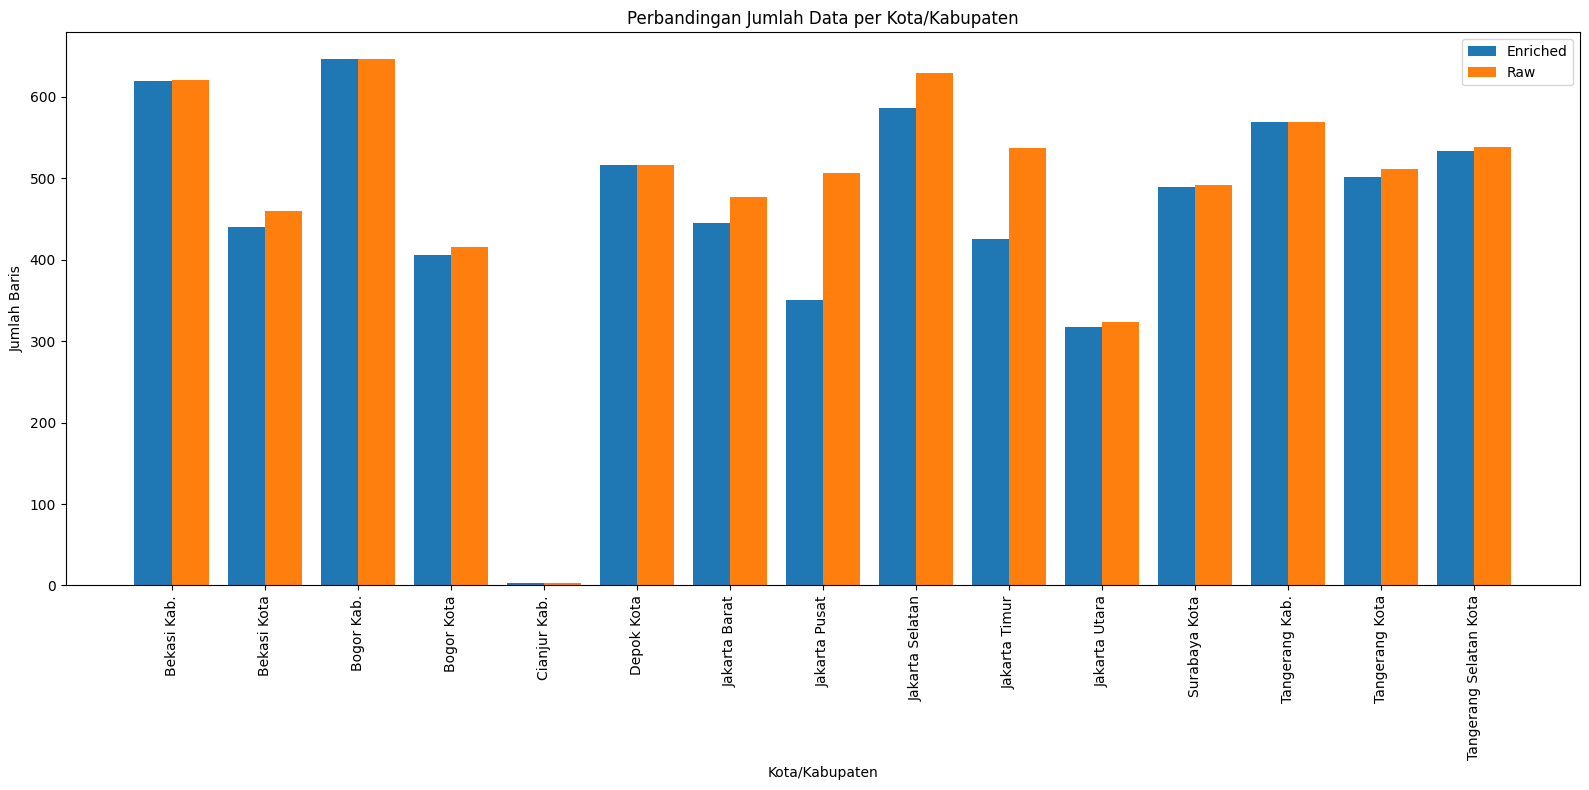

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_enriched = pd.read_csv("dataset_properti_enriched.csv")
df_raw = pd.read_csv("dataset_properti_raw.csv")

count_enriched = df_enriched["Kota/kabupaten"].value_counts()
count_raw = df_raw["Kota/kabupaten"].value_counts()

# Gabungkan hasil perhitungan
comparison_df = pd.DataFrame({
    "Enriched": count_enriched,
    "Raw": count_raw
}).fillna(0)

comparison_df = comparison_df.astype(int)

# Hitung selisih
comparison_df["Selisih"] = (
    comparison_df["Enriched"] - comparison_df["Raw"]
)

# Tabel Perbandingan
print("\nPerbandingan Jumlah Data per Kota/Kabupaten\n")
print(comparison_df.to_string())

# Grafik perbandingan
x = np.arange(len(comparison_df.index))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 8))

ax.bar(
    x - width/2,
    comparison_df["Enriched"],
    width,
    label="Enriched"
)

ax.bar(
    x + width/2,
    comparison_df["Raw"],
    width,
    label="Raw"
)

# Styling grafik
ax.set_title("Perbandingan Jumlah Data per Kota/Kabupaten")
ax.set_xlabel("Kota/Kabupaten")
ax.set_ylabel("Jumlah Baris")

ax.set_xticks(x)
ax.set_xticklabels(comparison_df.index, rotation=90)

ax.legend()

plt.tight_layout()
plt.show()

# Revisi Dataset (After Scraping)

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset_properti_enriched.csv")
initial_rows = len(df)

# HAPUS BARIS
# Hapus duplikasi 'ad_id'
df = df.drop_duplicates(subset=['ad_id'], keep='first')

df = df[df['ad_id'] != 934393840]

# Hapus baris Cianjur
df = df[df['Kota/kabupaten'] != "Cianjur Kab."]

# KOREKSI ARAH HADAP
arah_hadap_hapus_ids = [
    944030963, 944061169, 945170985, 937879206, 925432208, 945156694, 934367855, 
    944425556, 944426111, 944425040, 944425561, 944424989, 944425316, 944425868, 
    944425481, 944724123, 944425042, 944581349, 944424970, 928092136, 944425043, 
    944581238, 944581522, 944425552, 943041549, 944844821, 945179406, 938508490, 
    945138269, 944860551, 945035485, 943108736, 928529959, 943019064
]
df.loc[df['ad_id'].isin(arah_hadap_hapus_ids), 'Arah_Hadap'] = np.nan

def hapus_arah_spesifik(row, target_ids, arah_to_remove):
    if row['ad_id'] in target_ids and pd.notna(row['Arah_Hadap']):
        arah_list = [a.strip() for a in str(row['Arah_Hadap']).split(',')]
        arah_list = [a for a in arah_list if a != arah_to_remove]
        return ", ".join(arah_list) if arah_list else np.nan
    return row['Arah_Hadap']

df['Arah_Hadap'] = df.apply(lambda row: hapus_arah_spesifik(row, [939536895], 'Barat'), axis=1)
df['Arah_Hadap'] = df.apply(lambda row: hapus_arah_spesifik(row, [944038202], 'Utara'), axis=1)
df['Arah_Hadap'] = df.apply(lambda row: hapus_arah_spesifik(row, [943843041, 935269550], 'Selatan'), axis=1)
df['Arah_Hadap'] = df.apply(lambda row: hapus_arah_spesifik(row, [945142749, 943680337, 941762806, 941762817, 942037585, 943919562], 'Timur'), axis=1)

# KOREKSI KAMAR MANDI TAMU & LANTAI
# Ubah Null menjadi 0
df['Kamar_Mandi_Tamu'] = df['Kamar_Mandi_Tamu'].fillna(0).replace("", 0)

# Paksa tipe data Lantai menjadi numerik, ubah yang <= 0 menjadi 1
df['Lantai'] = pd.to_numeric(df['Lantai'], errors='coerce')
df.loc[df['Lantai'] <= 0, 'Lantai'] = 1

df.loc[df['Lantai'].isin([1.037, 175]), 'Lantai'] = 3
df.loc[df['Lantai'] == 850, 'Lantai'] = 2.5
df.loc[df['Lantai'].isin([185, 140]), 'Lantai'] = 1.5
df.loc[df['Lantai'].isin([2026, 2025]), 'Lantai'] = 1
df.loc[df['Lantai'].isin([2200, 480, 55, 84]), 'Lantai'] = 2

df.loc[df['ad_id'] == 942813152, 'Lantai'] = 3
df.loc[df['ad_id'].isin([930205099, 934938428, 944331767, 919479550, 943019064]), 'Lantai'] = 1
df.loc[df['ad_id'].isin([934852852, 934852652]), 'Lantai'] = 2
df.loc[df['ad_id'] == 944055381, 'Lantai'] = 1.5
df.loc[df['ad_id'] == 939641979, 'Lantai'] = 2.5

# KOREKSI DAYA LISTRIK
def hapus_listrik(row, target_id, val_to_remove):
    if row['ad_id'] == target_id and pd.notna(row['Daya_Listrik (Watt)']):
        listrik_list = [l.strip() for l in str(row['Daya_Listrik (Watt)']).split('+')]
        listrik_list = [l for l in listrik_list if l != val_to_remove]
        return " + ".join(listrik_list) if listrik_list else np.nan
    return row['Daya_Listrik (Watt)']

df['Daya_Listrik (Watt)'] = df.apply(lambda row: hapus_listrik(row, 943575394, '250'), axis=1)

def tambah_listrik(row, target_ids, val_to_add):
    if row['ad_id'] in target_ids:
        curr = str(row['Daya_Listrik (Watt)']) if pd.notna(row['Daya_Listrik (Watt)']) and str(row['Daya_Listrik (Watt)']).strip() != "" else ""
        if curr:
            list_curr = [l.strip() for l in curr.split('+')]
            if val_to_add not in list_curr:
                return curr + " + " + val_to_add
            return curr
        return val_to_add
    return row['Daya_Listrik (Watt)']

df['Daya_Listrik (Watt)'] = df.apply(lambda row: tambah_listrik(row, [925432208], '16000'), axis=1)
df['Daya_Listrik (Watt)'] = df.apply(lambda row: tambah_listrik(row, [944222267], '5500'), axis=1)
df['Daya_Listrik (Watt)'] = df.apply(lambda row: tambah_listrik(row, [944036921, 944778633], '3500'), axis=1)
df['Daya_Listrik (Watt)'] = df.apply(lambda row: tambah_listrik(row, [944104999], '13000'), axis=1)
df['Daya_Listrik (Watt)'] = df.apply(lambda row: tambah_listrik(row, [944109576], '2200'), axis=1)

ganti_listrik_map = {
    916226315: '11000',
    941877943: '13000',
    939640055: '14000',
    943038980: '10000'
}
for ad_id, val in ganti_listrik_map.items():
    df.loc[df['ad_id'] == ad_id, 'Daya_Listrik (Watt)'] = val

# KOREKSI SERTIFIKAT
def tambah_sertifikat(row, target_ids, val_to_add):
    if row['ad_id'] in target_ids:
        curr = str(row['Sertifikat']) if pd.notna(row['Sertifikat']) and str(row['Sertifikat']).strip() != "" else ""
        if curr:
            certs = [c.strip() for c in curr.split(',')]
            if val_to_add not in certs:
                certs.append(val_to_add)
                return ", ".join(certs)
            return curr
        return val_to_add
    return row['Sertifikat']

pbb_ids = [944060817, 935706031, 942813152, 942640332, 945163399, 945076844, 945066389, 945066276, 935326044, 945138269]
shm_ids = [930401837, 930920700, 939641979, 925432208]
df['Sertifikat'] = df.apply(lambda row: tambah_sertifikat(row, pbb_ids, 'PBB'), axis=1)
df['Sertifikat'] = df.apply(lambda row: tambah_sertifikat(row, shm_ids, 'SHM'), axis=1)
df['Sertifikat'] = df.apply(lambda row: tambah_sertifikat(row, [945179406], 'SHMSRS'), axis=1)
df['Sertifikat'] = df.apply(lambda row: tambah_sertifikat(row, [938508490], 'STRATA TITLE'), axis=1)

# KOREKSI LUAS TANAH
df.loc[df['ad_id'].isin([908164066, 935205215]), 'Luas_tanah'] = 0

# KOREKSI LUAS BANGUNAN
df.loc[df['ad_id'] == 944047828, 'Luas_bangunan'] = 72
df.loc[df['ad_id'] == 944864538, 'Luas_bangunan'] = 45
df.loc[df['ad_id'] == 940823990, 'Luas_bangunan'] = 38

# KOREKSI TIPE
df.loc[df['ad_id'] == 931512214, 'Tipe'] = 'rumah'

# Ubah tipe data kolom utama menjadi numerik
cols_to_numeric = ['price', 'lat', 'lon', 'Luas_bangunan', 'Luas_tanah', 'Kamar_tidur', 'Kamar_Mandi', 'Kamar_Mandi_Tamu']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Bersihkan spasi ganda
if df['Arah_Hadap'].dtype == object:
    df['Arah_Hadap'] = df['Arah_Hadap'].str.replace(r'\s+', ' ', regex=True).str.strip()

# Tambal teks kosong
cols_to_fill_empty = ['Tipe', 'Fasilitas_Indoor', 'Karakteristik_bangunan', 'Sertifikat', 'Daya_Listrik (Watt)', 'Arah_Hadap', 'Kelurahan/desa']
for col in cols_to_fill_empty:
    if col in df.columns:
        df[col] = df[col].fillna("")

output_filename = "dataset_properti_cleaned.csv"
df.to_csv(output_filename, index=False)

print(f"Total baris awal   : {initial_rows}")
print(f"Total baris akhir  : {len(df)}")

Total baris awal   : 6851
Total baris akhir  : 6847


# Revisi Dataset (Final)

In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset_properti_final.csv")

# NORMALISASI PENAMAAN KOLOM
rename_dict = {
    "ad_id": "ID_Iklan",
    "title": "Judul",
    "price": "Harga",
    "Tipe": "Tipe_Properti",
    "Luas_tanah": "Luas_Tanah",
    "Luas_bangunan": "Luas_Bangunan",
    "Kamar_tidur": "Kamar_Tidur",
    "Kamar_Mandi": "Kamar_Mandi",
    "Kamar_Mandi_Tamu": "Kamar_Mandi_Tamu",
    "Lantai": "Lantai",
    "Daya_Listrik (Watt)": "Daya_Listrik_Watt",
    "Sertifikat": "Sertifikat",
    "Arah_Hadap": "Arah_Hadap",
    "Facilities": "Fasilitas",
    "Provinsi": "Provinsi",
    "Kota/kabupaten": "Kota_Kabupaten",
    "Kecamatan": "Kecamatan",
    "Kelurahan/desa": "Kelurahan_Desa",
    "lat": "Latitude",
    "lon": "Longitude",
    "parameter-external_source_url": "URL_Sumber",
    "description": "Deskripsi"
}
df = df.rename(columns=rename_dict)

# FINAL CLEANING & REFINEMENT
df["ID_Iklan"] = df["ID_Iklan"].astype(str)

string_cols = ["Tipe_Properti", "Sertifikat", "Arah_Hadap", "Fasilitas", "Provinsi", "Kota_Kabupaten", "Kecamatan", "Kelurahan_Desa"]
for col in string_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().replace("nan", "")

int_cols = ["Kamar_Tidur", "Kamar_Mandi", "Kamar_Mandi_Tamu"]
for col in int_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

df["Lantai"] = df["Lantai"].fillna(1.0).astype(float)

df["Latitude"] = df["Latitude"].round(5) # 5 desimal = akurasi ~1.1 meter
df["Longitude"] = df["Longitude"].round(5)

# PENATAAN URUTAN KOLOM
ordered_columns = [
    # 1. Identitas & Klasifikasi Utama
    "ID_Iklan", "Judul", "Tipe_Properti", "Harga", 
    
    # 2. Dimensi & Spesifikasi Fisik Struktur
    "Luas_Tanah", "Luas_Bangunan", "Kamar_Tidur", "Kamar_Mandi", "Kamar_Mandi_Tamu", "Lantai",
    
    # 3. Legalitas, Utilitas & Fitur Internal
    "Daya_Listrik_Watt", "Sertifikat", "Arah_Hadap", "Fasilitas",
    
    # 4. Atribut Geografis & Spasial
    "Provinsi", "Kota_Kabupaten", "Kecamatan", "Kelurahan_Desa", "Latitude", "Longitude",
    
    # 5. Informasi Pelengkap/Mentah
    "URL_Sumber", "Deskripsi"
]

# Urutkan kolom
final_column_structure = [col for col in ordered_columns if col in df.columns]
df = df[final_column_structure]

output_filename = "dataset_properti.csv"
df.to_csv(output_filename, index=False)

print(f"Struktur dataset saat ini: {df.shape[1]} kolom dan {df.shape[0]} baris.")

Struktur dataset saat ini: 22 kolom dan 6847 baris.


# Cek File .npy

In [8]:
import numpy as np

file_path = 'SBERT Model/semantic_embeddings.npy'

try:
    array_data = np.load(file_path)
    
    # Informasi dasar
    print("Shape array :", array_data.shape)
    print("Tipe data    :", array_data.dtype)
    print("Dimensi array        :", array_data.ndim)
    
    print("\nIsi data:\n", array_data)

except FileNotFoundError:
    print(f"File '{file_path}' tidak ditemukan. Pastikan path file sudah benar.")
except Exception as e:
    print(f"Terjadi kesalahan saat memuat file: {e}")

Shape array : (6847, 768)
Tipe data    : float32
Dimensi array        : 2

Isi data:
 [[-0.11727128 -0.00235889 -0.00857987 ...  0.05432513 -0.09490523
  -0.07752743]
 [-0.13512465  0.09983789 -0.0063705  ... -0.03290993 -0.03864596
  -0.07712968]
 [ 0.01779371 -0.09744188 -0.00572703 ... -0.04141259 -0.08582968
  -0.08415832]
 ...
 [-0.09382781  0.15386279 -0.0073371  ...  0.0219571  -0.0884953
  -0.05627184]
 [-0.09417272 -0.063722   -0.00837726 ...  0.02515122 -0.14472431
  -0.09189478]
 [-0.12810732  0.16148268 -0.01233959 ...  0.00890145 -0.08794725
  -0.06981842]]
